In [1]:
import sys
sys.path.append("/project/src")

In [2]:
# Helper imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sksurv.metrics import concordance_index_censored

from rsfmodel import RandomSurvivalForest
from preprocessing import (
    BaseDatasetPreprocessor,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
    split_features_target,
)

import wandb
import joblib

# Read datasets

In [3]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    train_df_csv = "/content/drive/MyDrive/bachelor/nacc_train_reduced.csv"
else:
    train_df_csv = "./data/nacc_train_reduced.csv"

In [4]:
train_df = pd.read_csv(train_df_csv, delimiter=',')

In [5]:
train_df.shape

(6499, 141)

## Compute X and y

In [6]:
train_X, train_y = split_features_target(train_df)

# Initialize wandb

In [7]:
features_num = train_X.shape[1]
n_samples = train_X.shape[0]

run = wandb.init(
    entity="semariik",
    project="survival-analysis-mci",
)

wandb.define_metric("trees/*", step_metric="trees/num_trees")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: mariik04 (semariik) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Parameters and constants definition

In [8]:
class NodeSizeDistribution:
    def __init__(self, n_samples):
        self.n = n_samples
    def rvs(self, random_state=None):
        rng = np.random.default_rng(random_state)
        x = rng.uniform(0, 1)
        return max(15, round(self.n ** x))

In [9]:
def rsf_concordance_scorer(estimator, X, y):
    try:
        risk_scores = estimator.predict(X)
        c_index = concordance_index_censored(
            y[SURVIVAL_EVENT_COL].astype(bool),
            y[SURVIVAL_TIME_COL],
            risk_scores
        )[0]
        return c_index

    except Exception as e:
        rsf_step = estimator.named_steps['model'] if hasattr(estimator, 'named_steps') else estimator
        print(f"Scorer failed — parameters that caused the error:")
        print(f"  min_node_size:   {rsf_step.min_node_size}")
        print(f"  mtry:            {rsf_step.mtry}")
        print(f"  replace:         {rsf_step.replace}")
        print(f"  sample_fraction: {rsf_step.sample_fraction:.4f}")
        print(f"  Error type:      {type(e).__name__}")
        print(f"  Error message:   {e}")
        raise

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
event_indicator = train_y[SURVIVAL_EVENT_COL].astype(int)
cv_splits = list(cv.split(train_X, event_indicator))

In [11]:
param_distributions = {
    'model__num_trees':        np.arange(100, 500, 50),
    'model__mtry':             ['sqrt', 'log2'],
    'model__min_node_size':    NodeSizeDistribution(n_samples),
    'model__replace':          [True, False],
    'model__sample_fraction':  uniform(0.1, 0.9),
}

In [12]:
rsf_tunning_pipeline = Pipeline([
  ('preprocessor', BaseDatasetPreprocessor()),
  ('model', RandomSurvivalForest())
])

# RSF model tunning

## Tune parameters with RandomizedSearchCV

In [13]:
random_search = RandomizedSearchCV(
    estimator=rsf_tunning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=cv_splits,
    scoring=rsf_concordance_scorer,
    refit=True,
)

random_search.fit(train_X, train_y)

# Log aggregated CV results to wandb
results_df = pd.DataFrame(random_search.cv_results_)
wandb.log({
    "cv/results_table": wandb.Table(dataframe=results_df[[
        "mean_test_score",
        "std_test_score",
        "param_model__num_trees",
        "param_model__mtry",
        "param_model__min_node_size",
        "param_model__replace",
        "param_model__sample_fraction",
    ]])
})

Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  




Running Random Survival Forest with parameters: num_trees=300, min_node_size=84, mtry=log2, splitrule='C', importance='none', compute_weights=True, replace=True, sample_fraction=0.4761930407613727
Growing trees.. Progress: 45%. Estimated remaining time: 37 seconds.
Growing trees.. Progress: 98%. Estimated remaining time: 1 seconds.
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns


Running Random Survival Forest with parameters: num_trees=300, min_node_size=84, mtry=log2, splitrule='C', importance='none', compute_weights=True, replace=True, sample_fraction=0.4761930407613727
Growing trees.. Progress: 47%. Estimated remaining time: 34 seconds.
Growing trees.. Progress: 97%. Estimated remaining time: 2 seconds.
Dropping useless columns and columns represented the MCI 

In [14]:
random_search.best_params_

{'model__min_node_size': 41,
 'model__mtry': 'sqrt',
 'model__num_trees': np.int64(450),
 'model__replace': True,
 'model__sample_fraction': np.float64(0.34445463687030875)}

## Assess overfitting and underfitting

Create OOB vs train error curves to check for overfitting and underfitting.

In [15]:
rsf_best_params = {
    k.replace('model__', ''): v
    for k, v in random_search.best_params_.items()
}
rsf_best_params

{'min_node_size': 41,
 'mtry': 'sqrt',
 'num_trees': np.int64(450),
 'replace': True,
 'sample_fraction': np.float64(0.34445463687030875)}

In [16]:
# Preprocess full training set using the best pipeline's fitted preprocessor
best_preprocessor = random_search.best_estimator_.named_steps['preprocessor']
X_train_preprocessed = best_preprocessor.transform(train_X)

Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator


In [23]:
tree_count = np.arange(100, 550, 50)
train_errors = []
oob_errors = []

for n_trees in tree_count:
    rsf = RandomSurvivalForest(
        num_trees=n_trees,
        mtry=rsf_best_params['mtry'],
        min_node_size=rsf_best_params['min_node_size'],
        replace=rsf_best_params['replace'],
        sample_fraction=rsf_best_params['sample_fraction'],
        splitrule="C",
        compute_weights=True,
        OOB_score=True,
    )
    rsf.fit(X_train_preprocessed, train_y)

    oob_error = rsf.oob_error()
    oob_errors.append(oob_error)
    train_error = 1 - rsf.score(X_train_preprocessed, train_y)
    train_errors.append(train_error)

    error_gap = oob_error - train_error

    # wandb.log({
    #     "trees/num_trees":   n_trees,
    #     "trees/oob_error":   oob_error,
    #     "trees/train_error": train_error,
    #     "trees/gap":         error_gap,
    # })



Running Random Survival Forest with parameters: num_trees=100, min_node_size=41, mtry=sqrt, splitrule='C', importance='none', compute_weights=True, replace=True, sample_fraction=0.34445463687030875
Growing trees.. Progress: 92%. Estimated remaining time: 2 seconds.


Running Random Survival Forest with parameters: num_trees=150, min_node_size=41, mtry=sqrt, splitrule='C', importance='none', compute_weights=True, replace=True, sample_fraction=0.34445463687030875
Growing trees.. Progress: 60%. Estimated remaining time: 20 seconds.


Running Random Survival Forest with parameters: num_trees=200, min_node_size=41, mtry=sqrt, splitrule='C', importance='none', compute_weights=True, replace=True, sample_fraction=0.34445463687030875
Growing trees.. Progress: 47%. Estimated remaining time: 34 seconds.
Growing trees.. Progress: 94%. Estimated remaining time: 3 seconds.


Running Random Survival Forest with parameters: num_trees=250, min_node_size=41, mtry=sqrt, splitrule='C', importance='none'

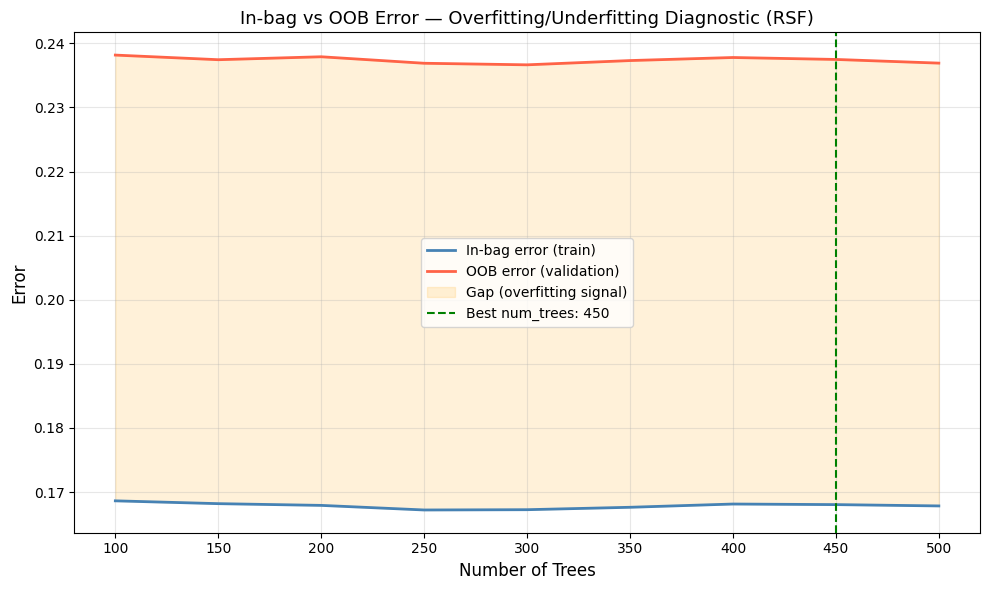

In [24]:
best_trees_num = random_search.best_params_['model__num_trees']

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tree_count, train_errors, color="steelblue", linewidth=2, label="In-bag error (train)")
ax.plot(tree_count, oob_errors,   color="tomato",    linewidth=2, label="OOB error (validation)")

ax.fill_between(
    tree_count, train_errors, oob_errors,
    alpha=0.15, color="orange", label="Gap (overfitting signal)"
)
ax.axvline(best_trees_num, color="green", linestyle="--", linewidth=1.5, label=f"Best num_trees: {best_trees_num}")

ax.set_xlabel("Number of Trees", fontsize=12)
ax.set_ylabel("Error", fontsize=12)
ax.set_title("In-bag vs OOB Error — Overfitting/Underfitting Diagnostic (RSF)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rsf_oob_inbag_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# wandb.log({"curves/rsf_oob_inbag_diagnostic": wandb.Image("rsf_oob_inbag_curves.png")})

# Store best parameters and pipeline

In [25]:
rsf_best_params

{'min_node_size': 41,
 'mtry': 'sqrt',
 'num_trees': np.int64(450),
 'replace': True,
 'sample_fraction': np.float64(0.34445463687030875)}

In [26]:
cv_cindex = random_search.best_score_
cv_cindex

np.float64(0.7636108266980608)

In [27]:
cv_cindex_std = random_search.cv_results_['std_test_score'][random_search.best_index_] 
cv_cindex_std

np.float64(0.015585118915280066)

In [ ]:
wandb.log({"best_parameters": rsf_best_params})
joblib.dump(rsf_best_params, "joblib-storage/rsf_best_params.joblib")
joblib.dump(random_search.best_estimator_, "joblib-storage/rsf_best_pipeline.joblib")
joblib.dump(cv_cindex, "joblib-storage/rsf_best_cv_cindex.joblib")
joblib.dump(cv_cindex_std, "joblib-storage/rsf_best_cv_cindex_std.joblib")
wandb.finish()

: 